In [25]:
import pandas as pd
import yfinance as yf 
import numpy as np
import altair as alt
import scipy
import lxml
import requests
from io import StringIO

<h1><center> Pull NASDAQ-100 Stock and Metadata Info from Wikipedia </center></h1>

In [26]:
# Import Nasdaq tickers from wikipedia

url = 'https://en.wikipedia.org/wiki/Nasdaq-100'
headers = {'User-Agent': 'Mozilla/5.0 (compatible; stock-analysis/1.0)'}
response = requests.get(url, headers = headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))
nasdaq100 = tables[5]
tickers = nasdaq100['Ticker'].to_list()

In [27]:
def get_nasdaq_100_at_date(target_date: str):
    """ 
    Fetches NASDAQ 100 Wikipedia data as of the target date using the Wikipedia
    revision history API. Returns tickers and revision ID.
    """

    api_url = 'https://en.wikipedia.org/w/api.php'
    headers = {'User-Agent': 'Mozilla/5.0(compatible: stock-analysis/ 1.0)'}

    # Find the closest revision to target date
    params = {
        'action': 'query',
        'titles': 'Nasdaq-100',  # correct article title (case-sensitive after first char)
        'prop': 'revisions',
        'rvprop': 'ids|timestamp',
        'rvstart': f'{target_date}T23:59:59Z',
        'rvdir': 'older',
        'rvlimit': 1,
        'format': 'json'
    }

    rev_data = requests.get(api_url, params=params, headers=headers).json()
    page = next(iter(rev_data['query']['pages'].values()))
    rev = page['revisions'][0] 
    rev_id, timestamp = rev['revid'], rev['timestamp']
    print(f'Historical Snapshot -> revision {rev_id} ({timestamp})')

    # Fetch HTML data for the specific revision
    html_url = f'https://en.wikipedia.org/w/index.php?title=Nasdaq-100&oldid={rev_id}'
    response = requests.get(html_url, headers=headers)
    tables = pd.read_html(StringIO(response.text))

    # Find the components table — column name varies across revisions
    ticker_col_candidates = ['Ticker', 'Symbol']
    for t in tables:
        for col in ticker_col_candidates:
            if col in t.columns:
                return t[col].tolist(), rev_id
    raise ValueError('Ticker table not found in historical revision - check the table index')


In [28]:
def build_survivorship_universe(current_tickers: list, start_date: str):
    """ 
    Diffs current vs historical Nasdaq-100 composition. Returns full
    universe + per-ticker status labels.
    """

    historical_tickers, _ = get_nasdaq_100_at_date(start_date)

    current_set = set(current_tickers)
    historical_set = set(historical_tickers)

    removed = historical_set - current_set # Survivorship bias candidates
    added = current_set - historical_set # New entrants since start date
    stable = current_set & historical_set

    print(f'\n--- Constituency  Changes ({start_date} -> today)---')
    print(f'Stable : {len(stable)}')
    print(f'Added : {len(added)} {sorted(added)}')
    print(f'Removed : {len(removed)} {sorted(removed)}')
    print(f'Full Universe : {len(historical_set | current_set)} ')

    status_map = (
        {t: 'current' for t in stable} |
        {t: 'added' for t in added} |
        {t: 'removed' for t in removed}
    )

    full_universe = sorted(historical_set | current_set)
    return full_universe, status_map, removed, added


ANALYSIS_START = '2026-01-01'
full_universe, status_map, removed_tickers, added_tickers = build_survivorship_universe(tickers, ANALYSIS_START)

Historical Snapshot -> revision 1330682349 (2026-01-01T21:48:52Z)

--- Constituency  Changes (2026-01-01 -> today)---
Stable : 98
Added : 3 ['LITE', 'SNDK', 'WMT']
Removed : 3 ['AZN', 'CSGP', 'TEAM']
Full Universe : 104 


In [29]:
print(tickers)

['ADBE', 'AMD', 'ABNB', 'ALNY', 'GOOGL', 'GOOG', 'AMZN', 'AEP', 'AMGN', 'ADI', 'AAPL', 'AMAT', 'APP', 'ARM', 'ASML', 'ADSK', 'ADP', 'AXON', 'BKR', 'BKNG', 'AVGO', 'CDNS', 'CHTR', 'CTAS', 'CSCO', 'CCEP', 'CTSH', 'CMCSA', 'CEG', 'CPRT', 'COST', 'CRWD', 'CSX', 'DDOG', 'DXCM', 'FANG', 'DASH', 'EA', 'EXC', 'FAST', 'FER', 'FTNT', 'GEHC', 'GILD', 'HON', 'IDXX', 'INSM', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'KHC', 'LRCX', 'LIN', 'LITE', 'MAR', 'MRVL', 'MELI', 'META', 'MCHP', 'MU', 'MSFT', 'MSTR', 'MDLZ', 'MPWR', 'MNST', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'ODFL', 'PCAR', 'PLTR', 'PANW', 'PAYX', 'PYPL', 'PDD', 'PEP', 'QCOM', 'REGN', 'ROP', 'ROST', 'SNDK', 'STX', 'SHOP', 'SBUX', 'SNPS', 'TMUS', 'TTWO', 'TSLA', 'TXN', 'TRI', 'VRSK', 'VRTX', 'WMT', 'WBD', 'WDC', 'WDAY', 'XEL', 'ZS']


In [30]:
# Download NASDAQ-100 from y-finance
nasdaq_100 = yf.download(
    tickers = full_universe,
    start = ANALYSIS_START,
    interval = '1d',
    auto_adjust = True
)['Close']

nasdaq_100 = round(nasdaq_100, 2)
print(f'Price Matrix: {nasdaq_100.shape} ({nasdaq_100.shape[1]} tickers x {nasdaq_100.shape[0]} days)')

[*********************100%***********************]  104 of 104 completed


Price Matrix: (98, 104) (104 tickers x 98 days)


In [31]:
# Pull metadata for NASDAQ-100 companies
records = []

for ticker in full_universe:
    try:
        info = yf.Ticker(ticker).info
        records.append({
            'ticker': ticker,
            'name': info.get('shortName'),
            'sector': info.get('sector'),
            'market_cap': info.get('market_cap'),
            'pe_ratio': info.get('trailingPE'),
            'beta': info.get('beta'),
            'status': status_map.get(ticker, 'current')
        })
    except Exception as e:
        print(f'Failed for {ticker}: {e}')
        records.append({ 
            'ticker': ticker, 
            'name': None, 
            'sector': None,
            'market_cap': None, 
            'pe_ratio': None, 
            'beta': None,
            'status': status_map.get(ticker, 'unknown')
            
            })

records = pd.DataFrame(records, columns = ([
                                            'ticker',
                                            'name',
                                            'sector',
                                            'market_cap',
                                            'pe_ratio',
                                            'beta',
                                            'status'
]))

records['status'].value_counts()



status
current    98
removed     3
added       3
Name: count, dtype: int64

In [32]:
records

,ticker,name,sector,market_cap,pe_ratio,beta,status
0,AAPL,Apple Inc.,Technology,None,37.432728,1.065,current
1,ABNB,"Airbnb, Inc.",Consumer Cyclical,None,32.679012,1.208,current
2,ADBE,Adobe Inc.,Technology,None,14.263403,1.417,current
3,ADI,"Analog Devices, Inc.",Technology,None,59.175858,1.194,current
4,ADP,"Automatic Data Processing, Inc.",Technology,None,21.017723,0.841,current
...,...,...,...,...,...,...,...
99,WDAY,"Workday, Inc.",Technology,None,39.795030,1.035,current
100,WDC,Western Digital Corporation,Technology,None,28.981450,2.158,current
101,WMT,Walmart Inc.,Consumer Defensive,None,42.348590,0.652,added
102,XEL,Xcel Energy Inc.,Utilities,None,23.365995,0.421,current


In [33]:
nasdaq_100

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
2026-01-02,270.51,133.01,333.30,272.89,250.81,286.73,114.07,400.17,268.20,223.47,...,251.60,175.48,220.46,452.13,28.51,205.79,187.61,112.31,74.13,220.57
2026-01-05,266.76,135.87,331.56,276.42,255.21,288.66,112.36,397.83,283.61,221.08,...,257.31,175.13,220.14,448.80,28.53,208.90,187.79,112.26,73.53,222.76
2026-01-06,261.87,138.02,335.99,292.03,258.98,293.17,113.31,406.40,295.27,214.35,...,254.35,189.89,220.67,468.38,28.47,210.30,219.28,113.89,73.88,222.03
2026-01-07,259.85,137.04,338.10,291.98,259.12,293.79,111.99,422.50,291.47,210.02,...,256.67,183.57,219.06,484.15,28.59,211.14,199.78,112.27,72.68,231.16
2026-01-08,258.56,138.66,339.04,298.23,263.49,276.58,114.19,399.40,280.94,204.68,...,252.38,186.28,222.29,469.68,28.32,209.79,187.59,112.62,72.84,220.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18,297.84,134.30,255.64,418.58,222.94,243.49,127.68,286.27,413.06,420.99,...,242.16,300.60,171.52,436.58,27.10,128.88,458.68,133.34,78.10,174.69
2026-05-19,298.97,131.16,254.99,414.31,220.44,244.16,128.92,294.30,406.40,414.05,...,238.14,302.31,170.71,434.31,27.09,129.34,455.80,134.20,79.73,175.25
2026-05-20,302.25,135.55,253.37,398.05,220.69,243.63,128.87,298.48,426.32,447.58,...,236.62,304.88,170.66,430.44,27.42,126.61,459.62,130.85,79.86,174.45
2026-05-21,304.99,134.25,244.10,384.21,220.08,240.19,129.61,300.51,427.36,449.59,...,238.08,298.39,171.60,433.54,27.10,121.85,486.46,121.34,80.20,171.01


<h1><center> Build NASDAQ-100 Market benchmark </center></h1>

In [34]:
ret_nasdaq_100 = nasdaq_100.pct_change().dropna()

In [35]:
# Create a random set of weights for portfolio

def give_weights():
    rand = np.random.random(len(nasdaq_100.columns))
    rand /= rand.sum()
    return rand

In [36]:
print(give_weights().sum()*100)

100.0


In [54]:
pf_exp, pf_stds, weights = [], [], []

for i in range(10000):
    W = give_weights()
    weights.append(W)
    daily_returns = np.dot(ret_nasdaq_100, W)
    pf_exp.append(daily_returns.mean()* 252)
    pf_stds.append(daily_returns.std()* np.sqrt(252))

In [55]:
simulated_port = pd.DataFrame({'pf_exp': pf_exp, 
                               'pf_stds': pf_stds,
                               'weights': weights})

In [56]:
simulated_port

,pf_exp,pf_stds,weights
0,0.365346,0.157188,"[0.0072368839043262965, 0.015960851387841198, ..."
1,0.483660,0.168610,"[0.01292136287098303, 0.012562893150955014, 0...."
2,0.310002,0.154402,"[0.008456144654249282, 0.0013519932419649122, ..."
3,0.351098,0.158647,"[0.0017686029283435819, 0.0035945247997145116,..."
4,0.390518,0.157514,"[0.0012269225460040556, 0.012824212062526152, ..."
...,...,...,...
9995,0.361480,0.161540,"[0.017482176232278313, 0.01801411515092702, 0...."
9996,0.443862,0.175903,"[0.0038711992949055094, 0.015149165472263594, ..."
9997,0.333804,0.160531,"[0.017764634215917657, 0.004691868346006599, 0..."
9998,0.354039,0.171898,"[0.005096451401502599, 0.014462560176393148, 0..."


<Axes: title={'center': 'Efficient Frontier - Monte Carlo Simulation'}, xlabel='Annualized Volatility', ylabel='Annualized return'>

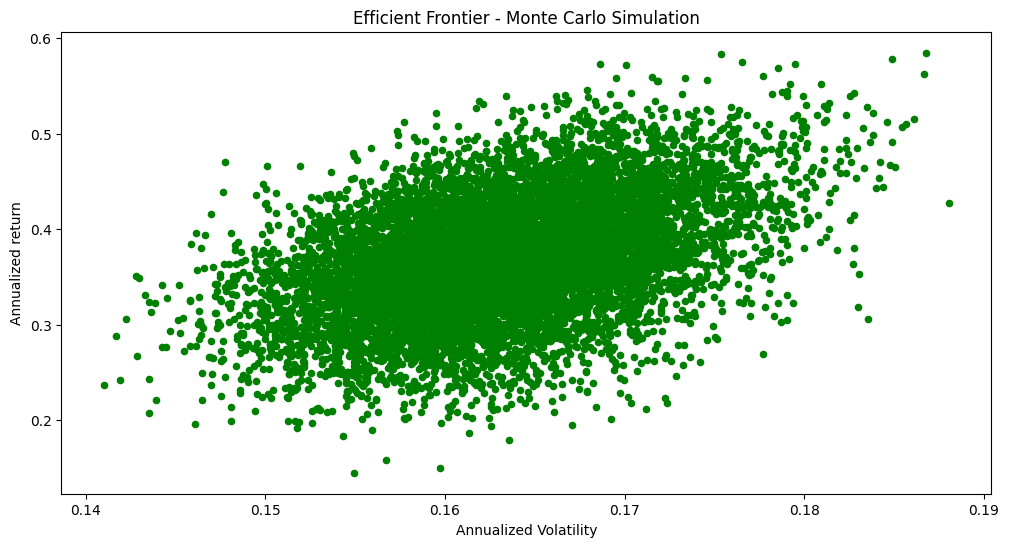

In [57]:
simulated_port.plot(x = 'pf_stds', 
               y = 'pf_exp', 
               kind = 'scatter', 
               color = 'green',
               figsize = (12, 6),
               title = 'Efficient Frontier - Monte Carlo Simulation',
               xlabel = 'Annualized Volatility',
               ylabel = 'Annualized return' 
               )


In [59]:
shp_ratio = simulated_port['pf_exp']/simulated_port['pf_stds']
shp_ratio

0       2.324258
1       2.868503
2       2.007761
3       2.213079
4       2.479260
          ...   
9995    2.237715
9996    2.523329
9997    2.079371
9998    2.059596
9999    2.099117
Length: 10000, dtype: float64

In [66]:
simulated_port.loc[shp_ratio.idxmax()]

pf_exp                                              0.572548
pf_stds                                             0.168629
weights    [0.018270096239905484, 0.0064347927659265496, ...
Name: 4357, dtype: object